<a href="https://colab.research.google.com/github/Khushi310105/Final_Year_Project/blob/main/chrononet_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%%capture
!pip install mne
!unzip "/content/drive/MyDrive/Colab Notebooks/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus.zip" -d .

In [4]:
from glob import glob
import scipy.io
import numpy as np
import mne

In [5]:
IDD_data_path='/content/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus/Data/CleanData/CleanData_IDD/Rest'
TDC_data_path='/content/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus/Data/CleanData/CleanData_TDC/Rest'
!rm '/content/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus/Data/CleanData/CleanData_IDD/Rest/NDS001_Rest_CD(1).mat'

In [6]:
def convertmat2mne(data):
  ch_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
  ch_types = ['eeg'] * 14
  sampling_freq=128
  info = mne.create_info(ch_names, ch_types=ch_types, sfreq=sampling_freq)
  info.set_montage('standard_1020')
  data=mne.io.RawArray(data, info)
  data.set_eeg_reference()
  data.filter(l_freq=1,h_freq=30)
  epochs=mne.make_fixed_length_epochs(data,duration=4,overlap=0)
  return epochs.get_data()


In [7]:
%%capture
idd_subject=[]
for idd in glob(IDD_data_path+'/*.mat'):
  data=scipy.io.loadmat(idd)['clean_data']
  data=convertmat2mne(data)
  idd_subject.append(data)

In [8]:
%%capture
tdc_subject=[]
for tdc in glob(TDC_data_path+'/*.mat'):
  data=scipy.io.loadmat(tdc)['clean_data']
  data=convertmat2mne(data)
  tdc_subject.append(data)

In [9]:
control_epochs_labels=[len(i)*[0] for i in tdc_subject]
patients_epochs_labels=[len(i)*[1] for i in idd_subject]
print(len(control_epochs_labels),len(patients_epochs_labels))

7 7


In [10]:
data_list=tdc_subject+idd_subject
label_list=control_epochs_labels+patients_epochs_labels
groups_list=[[i]*len(j) for i, j in enumerate(data_list)]
print(len(data_list),len(label_list),len(groups_list))

14 14 14


In [11]:
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
gkf=GroupKFold()
from sklearn.base import TransformerMixin,BaseEstimator
from sklearn.preprocessing import StandardScaler
#https://stackoverflow.com/questions/50125844/how-to-standard-scale-a-3d-matrix
class StandardScaler3D(BaseEstimator,TransformerMixin):
    #batch, sequence, channels
    def __init__(self):
        self.scaler = StandardScaler()

    def fit(self,X,y=None):
        self.scaler.fit(X.reshape(-1, X.shape[2]))
        return self

    def transform(self,X):
        return self.scaler.transform(X.reshape( -1,X.shape[2])).reshape(X.shape)

In [12]:
data_array=np.concatenate(data_list)
label_array=np.concatenate(label_list)
group_array=np.concatenate(groups_list)
data_array=np.moveaxis(data_array,1,2)

print(data_array.shape,label_array.shape,group_array.shape)

(420, 512, 14) (420,) (420,)


In [13]:
accuracy=[]
for train_index, val_index in gkf.split(data_array, label_array, groups=group_array):
    train_features,train_labels=data_array[train_index],label_array[train_index]
    val_features,val_labels=data_array[val_index],label_array[val_index]
    scaler=StandardScaler3D()
    train_features=scaler.fit_transform(train_features)
    val_features=scaler.transform(val_features)


    break

In [14]:
train_features.shape,val_features.shape

((330, 512, 14), (90, 512, 14))

In [15]:
from tensorflow.keras.layers import Input,Dense,concatenate,Flatten,GRU,Conv1D
from tensorflow.keras.models import Model

In [16]:
def block(input):
  conv1 = Conv1D(32, 2, strides=2,activation='relu',padding="same")(input)
  conv2 = Conv1D(32, 4, strides=2,activation='relu',padding="causal")(input)
  conv3 = Conv1D(32, 8, strides=2,activation='relu',padding="causal")(input)
  x = concatenate([conv1,conv2,conv3],axis=2)
  return x

In [17]:
input= Input(shape=(512,14))
block1=block(input)
block2=block(block1)
block3=block(block2)

In [18]:
gru_out1 = GRU(32,activation='tanh',return_sequences=True)(block3)
gru_out2 = GRU(32,activation='tanh',return_sequences=True)(gru_out1)
gru_out = concatenate([gru_out1,gru_out2],axis=2)
gru_out3 = GRU(32,activation='tanh',return_sequences=True)(gru_out)
gru_out = concatenate([gru_out1,gru_out2,gru_out3])
gru_out4 = GRU(32,activation='tanh')(gru_out)

In [19]:
predictions = Dense(1,activation='sigmoid')(gru_out4)
model = Model(inputs=input, outputs=predictions)

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics=['accuracy'])

In [20]:
history = model.fit(train_features,train_labels,epochs=10,batch_size=128,validation_data=(val_features,val_labels))

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 505ms/step - accuracy: 0.5091 - loss: 0.6925 - val_accuracy: 0.3333 - val_loss: 0.7193
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6424 - loss: 0.6412 - val_accuracy: 0.9667 - val_loss: 0.6024
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9515 - loss: 0.5551 - val_accuracy: 0.8889 - val_loss: 0.4972
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9697 - loss: 0.3723 - val_accuracy: 0.9889 - val_loss: 0.2064
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9697 - loss: 0.1864 - val_accuracy: 0.9889 - val_loss: 0.1429
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0633 - val_accuracy: 1.0000 - val_loss: 0.0505
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0213 - val_accuracy: 0.9667 - val_loss: 0.0657
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.0043

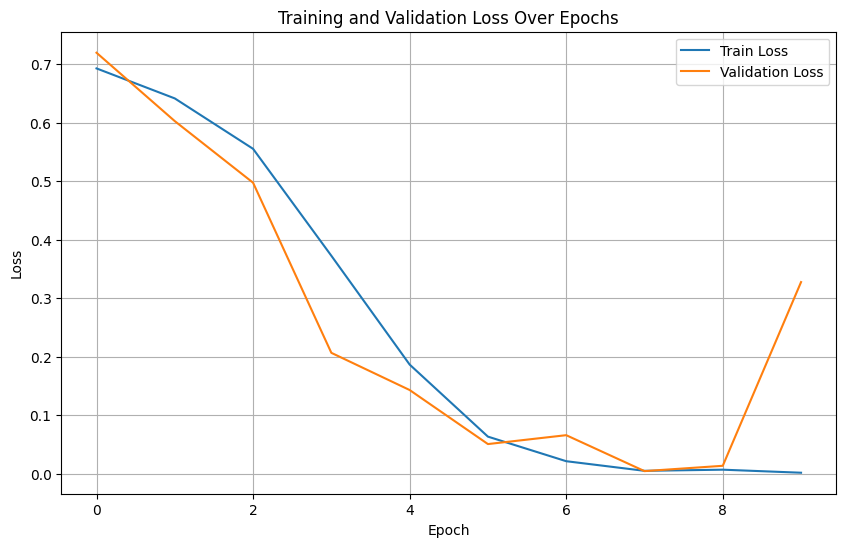

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

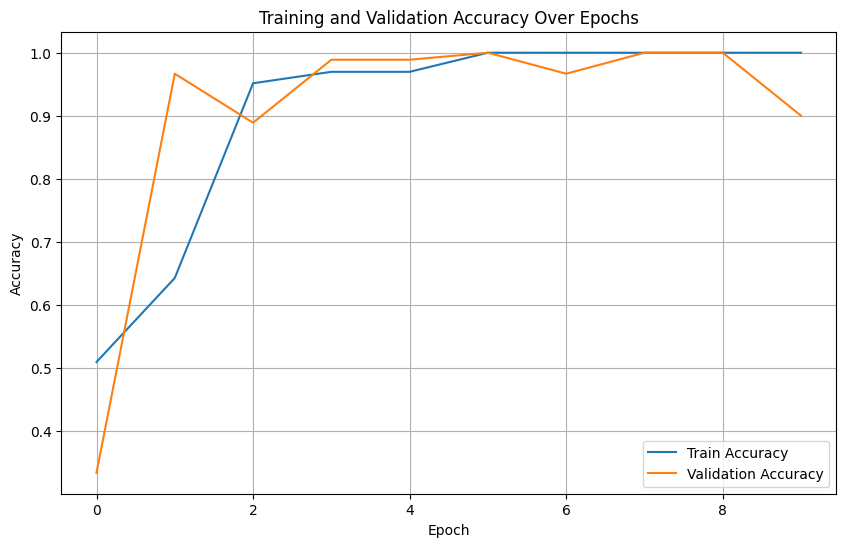

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
model.evaluate(val_features,val_labels)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - accuracy: 0.9000 - loss: 0.3274


[0.3273591697216034, 0.8999999761581421]

In [24]:
from sklearn.metrics import confusion_matrix
val_predictions = model.predict(val_features)
val_predicted_labels = (val_predictions > 0.5).astype(int)
cm = confusion_matrix(val_labels, val_predicted_labels)
print("Confusion Matrix:")
print(cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step
Confusion Matrix:
[[30  0]
 [ 9 51]]
